# EDA — Credit-Card Transactions

**Objective.** Characterise the bank credit-card dataset (PCA-anonymised features `V1–V28` plus `Time` and `Amount`) and quantify its extreme class imbalance.

> This notebook requires `data/raw/creditcard.csv`. If the file is absent the notebook short-circuits with a clear message so the rest of the pipeline still executes.

In [1]:
import sys
from pathlib import Path

# Make the project root importable so `from src import ...` resolves.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

from src import config
config.ensure_dirs()
FIG = config.FIGURES_DIR


In [2]:
from src import data_loader as dl, cleaning
from src.resampling import class_distribution

HAVE_CC = config.CREDITCARD_RAW.exists()
if not HAVE_CC:
    print('creditcard.csv not found in data/raw/ — skipping analysis.')
else:
    cc = dl.load_creditcard()
    print('Raw shape:', cc.shape)
    display(cc.head())

Raw shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Overview, dtypes & data quality

In [3]:
if HAVE_CC:
    cc.info()
    print('\nMissing values:')
    print(cleaning.missing_value_report(cc) if not cleaning.missing_value_report(cc).empty else 'None')
    print('Exact duplicate rows:', cc.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Exact duplicate rows: 1081


In [4]:
if HAVE_CC:
    cc = cleaning.clean_creditcard(cc)
    print('Cleaned shape (post dedup):', cc.shape)

Cleaned shape (post dedup): (283726, 31)


## 2. Class imbalance

,count,pct
Class,,
0,283253,99.833
1,473,0.167


Fraud rate: 0.1667%


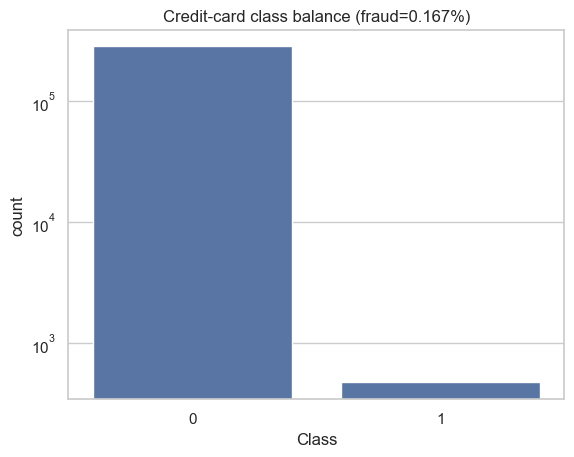

In [5]:
if HAVE_CC:
    dist = class_distribution(cc['Class'])
    display(dist)
    rate = cc['Class'].mean()
    print(f'Fraud rate: {rate:.4%}')
    ax = sns.countplot(x='Class', data=cc)
    ax.set(title=f'Credit-card class balance (fraud={rate:.3%})', yscale='log')
    plt.savefig(FIG / 'cc_class_balance.png', dpi=120, bbox_inches='tight')
    plt.show()

## 3. Univariate: Amount and Time

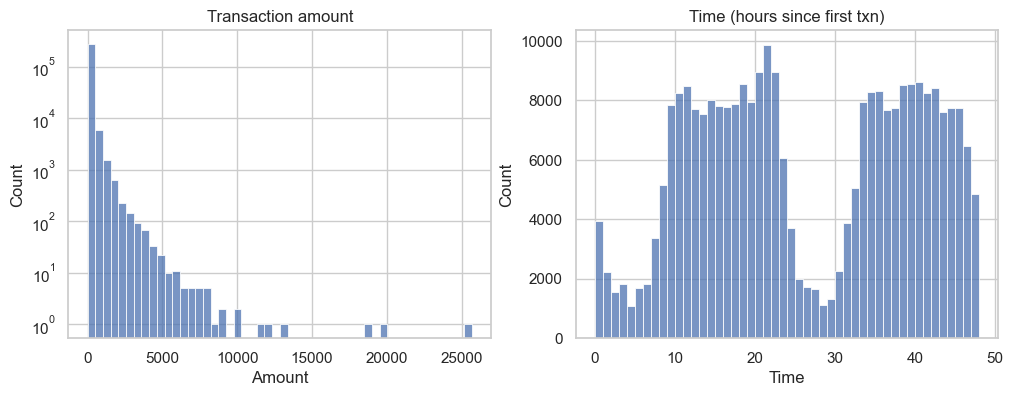

,Amount,Time
count,283726.000000,283726.000000
mean,88.472687,94811.077600
std,250.399437,47481.047891
min,0.000000,0.000000
25%,5.600000,54204.750000
50%,22.000000,84692.500000
75%,77.510000,139298.000000
max,25691.160000,172792.000000


In [6]:
if HAVE_CC:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(cc['Amount'], bins=50, ax=axes[0])
    axes[0].set(title='Transaction amount', yscale='log')
    sns.histplot(cc['Time'] / 3600, bins=48, ax=axes[1])
    axes[1].set(title='Time (hours since first txn)')
    plt.savefig(FIG / 'cc_univariate.png', dpi=120, bbox_inches='tight')
    plt.show()
    display(cc[['Amount', 'Time']].describe())

## 4. Bivariate: Amount vs class & feature correlations with target

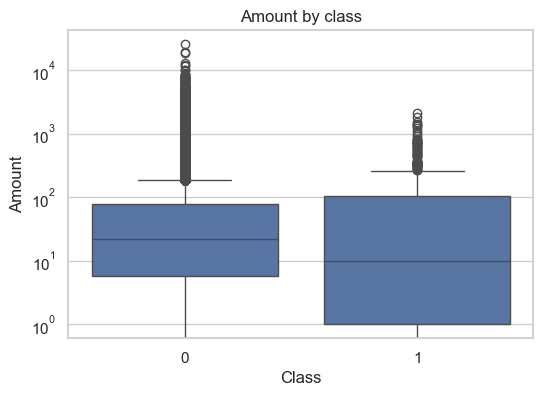

In [7]:
if HAVE_CC:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(x='Class', y='Amount', data=cc, ax=ax)
    ax.set(title='Amount by class', yscale='log')
    plt.savefig(FIG / 'cc_amount_by_class.png', dpi=120, bbox_inches='tight')
    plt.show()

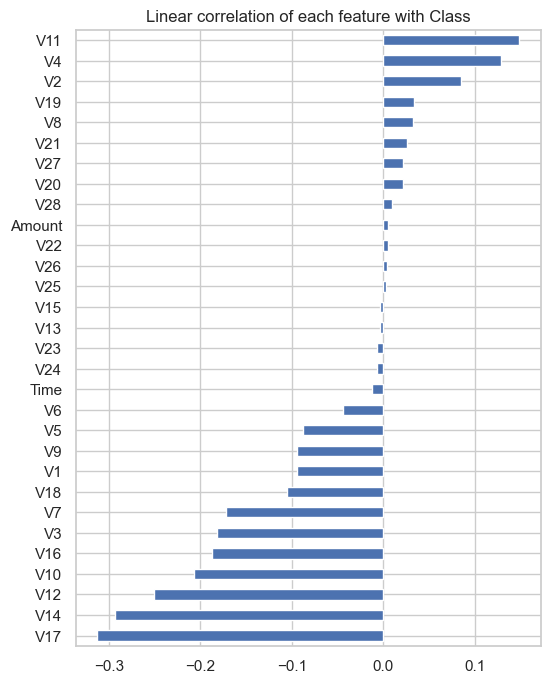

Most negatively/positively correlated PCA features:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V19    0.033631
V2     0.084624
V4     0.129326
V11    0.149067
Name: Class, dtype: float64


In [8]:
if HAVE_CC:
    corr = cc.corr(numeric_only=True)['Class'].drop('Class').sort_values()
    fig, ax = plt.subplots(figsize=(6, 8))
    corr.plot.barh(ax=ax)
    ax.set_title('Linear correlation of each feature with Class')
    plt.savefig(FIG / 'cc_target_correlation.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Most negatively/positively correlated PCA features:')
    print(pd.concat([corr.head(4), corr.tail(4)]))

## 5. Key findings

- **Extreme imbalance** (~0.17% fraud) — far more severe than Fraud_Data. Undersampling would discard ~99% of data; **SMOTE / SMOTEENN on the training fold only** is the appropriate response, and **AUC-PR** is the primary metric.
- `Amount` is heavily right-skewed and should be **scaled** (it is the only non-PCA numeric besides `Time`).
- Several PCA components (e.g. V14, V12, V17, V10) carry strong linear signal toward the target.